In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Loading all 5 Datasets
df_2015 = pd.read_csv("2015.csv")
df_2016 = pd.read_csv("2016.csv")
df_2017 = pd.read_csv("2017.csv")
df_2018 = pd.read_csv("2018.csv")
df_2019 = pd.read_csv("2019.csv")

In [38]:
# Checking Columns of Each
print("2015 columns:", df_2015.columns.tolist())
print("2016 columns:", df_2016.columns.tolist())
print("2017 columns:", df_2017.columns.tolist())
print("2018 columns:", df_2018.columns.tolist())
print("2019 columns:", df_2019.columns.tolist())

2015 columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2016 columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2017 columns: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
2018 columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
2019 columns: ['Overall rank', 'Country or region'

In [39]:
# Standardize all dataframes to same column names
df_2015 = df_2015[['Country', 'Happiness Score', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
                   'Freedom', 'Generosity', 'Trust (Government Corruption)']].copy()
df_2015.columns = ['Country', 'Score', 'GDP', 'Social_Support', 'Life Expectancy',
                   'Freedom', 'Generosity', 'Corruption']
df_2015["Year"] =  2015

df_2016 = df_2016[['Country', 'Happiness Score', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
                   'Freedom', 'Generosity', 'Trust (Government Corruption)']].copy()
df_2016.columns = ['Country', 'Score', 'GDP', 'Social_Support', 'Life Expectancy',
                   'Freedom', 'Generosity', 'Corruption']
df_2016["Year"] =  2016

df_2017 = df_2017[['Country', 'Happiness.Score', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.',
                   'Freedom', 'Generosity', 'Trust..Government.Corruption.']].copy()
df_2017.columns = ['Country', 'Score', 'GDP', 'Social_Support', 'Life Expectancy',
                   'Freedom', 'Generosity', 'Corruption']
df_2017["Year"] =  2017

df_2018 = df_2018[['Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
                   'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']].copy()
df_2018.columns = ['Country', 'Score', 'GDP', 'Social_Support', 'Life Expectancy',
                   'Freedom', 'Generosity', 'Corruption']
df_2018["Year"] =  2018

df_2019 = df_2019[['Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
                   'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']].copy()
df_2019.columns = ['Country', 'Score', 'GDP', 'Social_Support', 'Life Expectancy',
                   'Freedom', 'Generosity', 'Corruption']
df_2019["Year"] =  2019

In [42]:
# Combining all years
df = pd.concat([df_2015, df_2016, df_2017, df_2018, df_2019], ignore_index=True)
print(df.shape)
print(df.head())
print(df.isnull().sum())

(782, 9)
       Country  Score      GDP  Social_Support  Life Expectancy  Freedom  \
0  Switzerland  7.587  1.39651         1.34951          0.94143  0.66557   
1      Iceland  7.561  1.30232         1.40223          0.94784  0.62877   
2      Denmark  7.527  1.32548         1.36058          0.87464  0.64938   
3       Norway  7.522  1.45900         1.33095          0.88521  0.66973   
4       Canada  7.427  1.32629         1.32261          0.90563  0.63297   

   Generosity  Corruption  Year  
0     0.29678     0.41978  2015  
1     0.43630     0.14145  2015  
2     0.34139     0.48357  2015  
3     0.34699     0.36503  2015  
4     0.45811     0.32957  2015  
Country            0
Score              0
GDP                0
Social_Support     0
Life Expectancy    0
Freedom            0
Generosity         0
Corruption         1
Year               0
dtype: int64


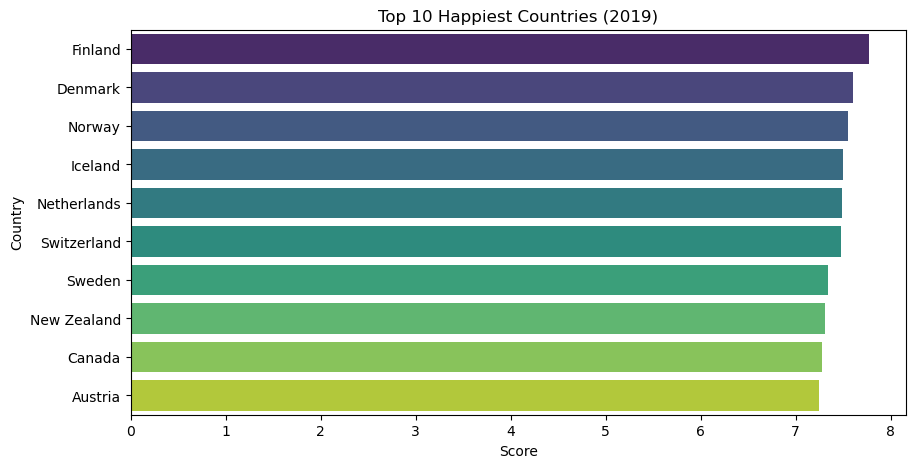

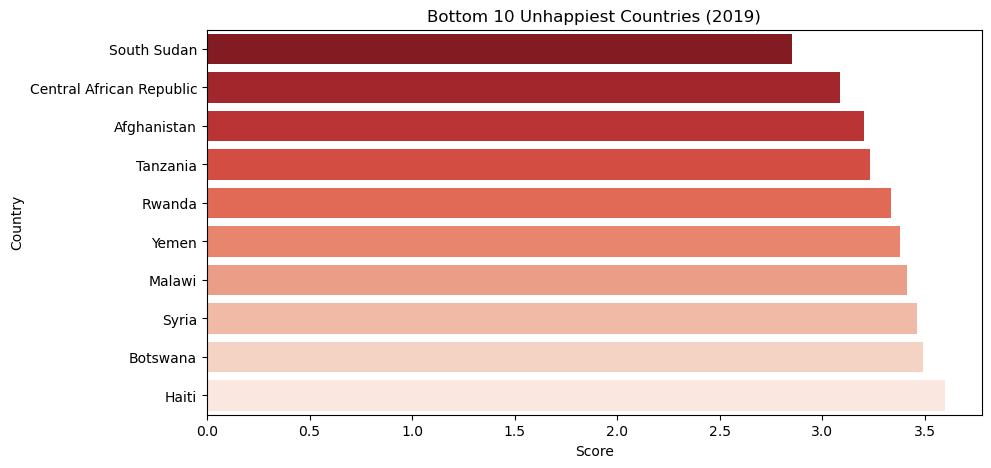

In [55]:
# 1. Top 10 Happiest Countries (2019)
plt.figure(figsize=(10,5))
top10 = df[df['Year']==2019].nlargest(10, 'Score')
sns.barplot(x="Score", y='Country', data=top10, palette='viridis')
plt.title("Top 10 Happiest Countries (2019)")
plt.show()

# 2. Bottom 10 Unhappiest Countries (2019)
plt.figure(figsize=(10,5))
bottom10 = df[df['Year']==2019].nsmallest(10, 'Score')
sns.barplot(x="Score", y='Country', data=bottom10, palette='Reds_r')
plt.title("Bottom 10 Unhappiest Countries (2019)")
plt.show()

In [56]:
# Insights from charts:
#	∙	Happiest: Finland, Denmark, Norway, Iceland — all Nordic countries! Small, wealthy, low corruption
#	∙	Unhappiest: South Sudan, Central African Republic, Afghanistan — all conflict zones or extreme poverty

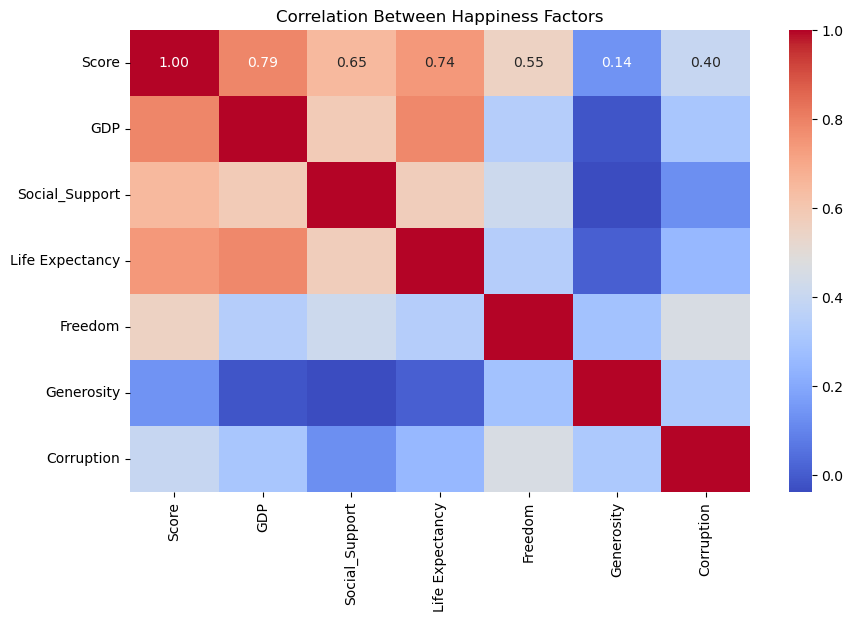

In [58]:
# Correlation heatmap - which features relate to happiness?
plt.figure(figsize=(10,6))
correlation = df[['Score', 'GDP', 'Social_Support', 
                  'Life Expectancy', 'Freedom', 
                  'Generosity', 'Corruption']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Happiness Factors')
plt.show()

In [60]:
# The Big Answer: Does Money =  Happiness?
# YES! GDP has 0.79 Correlation with happiness score.

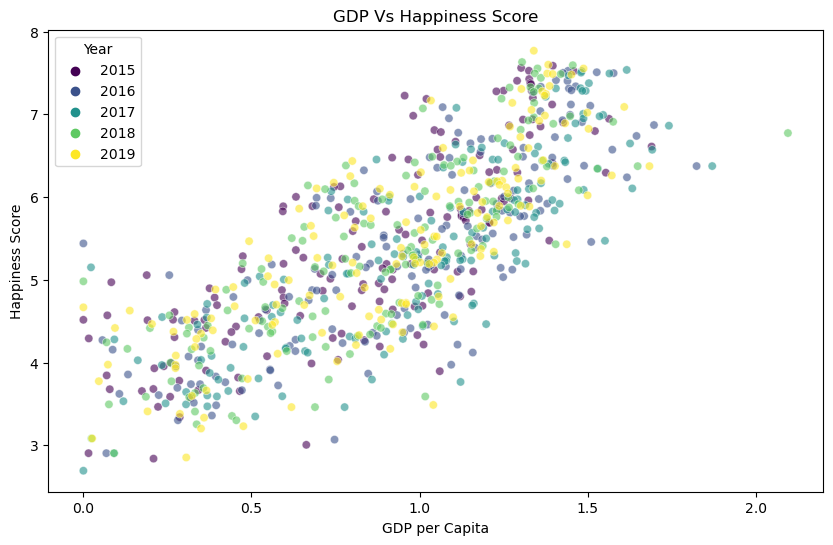

In [64]:
# Scatteplot - GDP Vs Happiness Score
plt.figure(figsize=(10,6))
sns.scatterplot(x='GDP', y='Score', data=df, hue='Year', palette='viridis', alpha=0.6)
plt.title('GDP Vs Happiness Score')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.show()

In [66]:
# Key insights:
# Clear upward trend — as GDP increases, happiness increases. This confirms our 0.79 correlation!
# Bottom left — low GDP, low happiness — poor countries like Afghanistan, South Sudan
# Top right — high GDP, high happiness — rich countries like Finland, Denmark, Norway
# But notice — some dots at low GDP still have decent happiness (around 5-6). This means money isn’t everything

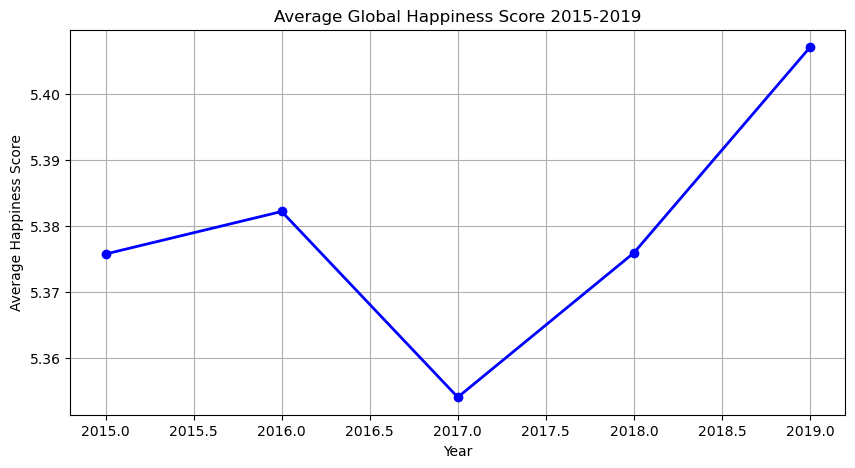

Year
2015    5.375734
2016    5.382185
2017    5.354019
2018    5.375917
2019    5.407096
Name: Score, dtype: float64


In [65]:
# Average happiness per year - trend analysis
plt.figure(figsize=(10,5))
yearly_avg = df.groupby('Year')['Score'].mean()
plt.plot(yearly_avg.index, yearly_avg.values, 
         marker='o', color='blue', linewidth=2)
plt.title('Average Global Happiness Score 2015-2019')
plt.xlabel('Year')
plt.ylabel('Average Happiness Score')
plt.grid(True)
plt.show()

print(yearly_avg)

In [67]:
# Key insights:
#	∙	2017 was the worst year globally for happiness
#	∙	2019 was the best year in this dataset
#	∙	Overall trend is slightly upward — world is getting slightly happier
#	∙	But the change is very small — only 0.03 difference between lowest and highes

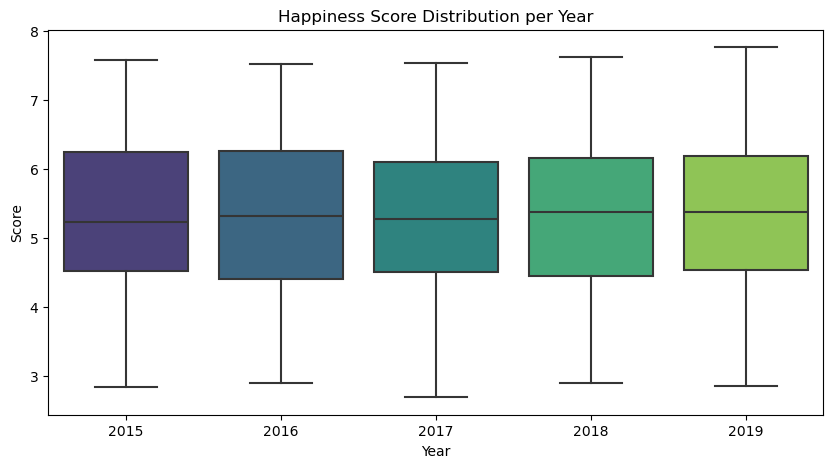

In [69]:
# Boxplot -  Happiness Score Distribution per Year
plt.figure(figsize=(10,5))
sns.boxplot(x='Year', y='Score', data=df, palette='viridis')
plt.title('Happiness Score Distribution per Year')
plt.show()

In [70]:
# Key insights:
#	∙	All 5 years look very similar — happiness distribution is stable
#	∙	Median is around 5.1-5.3 every year
#	∙	Range is always roughly 3 to 7.5
#	∙	2019 box is slightly higher — confirms world got slightly happier
#	∙	No outliers visible — no extremely unusual countries

In [71]:
# The big picture from all our EDA:
#	1.	Nordic countries dominate top 10 every year
#	2.	Conflict zones dominate bottom 10
#	3.	GDP is strongest predictor of happiness (0.79)
#	4.	World happiness is very stable — barely changes year to year
#	5.	2017 was worst year, 2019 was bes